In [10]:
print("Hello World!")

Hello World!


In [11]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [12]:
!pip install ipykernel


In [13]:
import torch

# 1. Check if CUDA is available
print(f"CUDA available: {torch.cuda.is_available()}")

# 2. Get the name of the active GPU
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

CUDA available: True
GPU Name: NVIDIA GeForce RTX 5070 Laptop GPU
CUDA Version: 12.8


In [14]:
!pip install sumo

In [422]:
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

import xml.etree.ElementTree as ET
import traci


In [423]:
import importlib

import functions.analysis as analysis
importlib.reload(analysis)


<module 'functions.analysis' from 'c:\\Users\\Yura Sannikov\\Учеба\\НИР-диплом26\\Папка с кодомм\\git\\functions\\analysis.py'>

In [244]:
def initialize(grids=3,lanes=2,length=200):
    os.system("netgenerate --grid --grid.number="+str(grids)+" -L="+str(lanes)+" --tls.guess --grid.length="+str(length)+" --output-file=grid.net.xml")
    # os.system("netgenerate --grid --grid.number="+str(grids)+" -L="+str(lanes)+" --tls.guess --grid.length="+str(length)+" --output-file=output_net.net.xml")
    # os.system("netconvert -s output_net.net.xml --tls.all traffic_light -o grid.net.xml")

In [245]:
def get_passed_count(detector_id):
    # Get the list of vehicles that passed the detector in the last step
    vehicle_data = traci.inductionloop.getLastIntervalVehicleNumber(detector_id)
    # The count is the length of the data list
    return vehicle_data
    # return len(vehicle_data)


In [287]:
def create_additional_with_e1_detectors(net_xml_path, path_to_save_data, output_path="additional.xml"):
    '''
    net_xml_path - путь до папки с сетью дорог
    path_to_save_data - путь до папки, куда будет сохраняться информация симуляции для каждого детектора
    output_path - выходной файл, для grid.sumocfg
    
    '''
    tree = ET.parse(net_xml_path)
    root = tree.getroot()
    
    additional_root = ET.Element("additional")
    
    # Находим все junction и их входящие lane
    for junction in root.findall("junction"):
        junction_id = junction.get("id")
        if not junction_id:
            continue
        
        # Ищем все connection, ведущие к этому junction
        connections = root.findall(f".//connection[@tl='{junction_id}']")
        lanes = set()
        for conn in connections:
            edge_id = conn.get("from")
            lane_idx = conn.get("fromLane")
            if edge_id and lane_idx:
                lanes.add(f"{edge_id}_{lane_idx}")
        
        # Создаем детектор E1 для каждой полосы
        for i, lane_id in enumerate(lanes):
            detector = ET.SubElement(additional_root, "inductionLoop")
            detector.set("id", f"{junction_id}_E1_{i}")
            detector.set("lane", lane_id)
            detector.set("pos", "-10")
            detector.set("period", "1")
            os.makedirs(path_to_save_data, exist_ok=True)
            detector.set("file", f"{path_to_save_data}/detector_{junction_id}_{i}.xml")
    
    tree_out = ET.ElementTree(additional_root)
    ET.indent(tree_out, space="  ")
    tree_out.write(output_path, encoding="UTF-8", xml_declaration=True)

In [310]:
def setTrafficLightFazes(traci, id, green_light_duration, red_light_duration):
    phases = []
    # Установка продолжительности зеленого сигнала
    phases.append(traci.trafficlight.Phase(green_light_duration, "GGgrrrrrGGgrrrrr", 0, 0))
    # Установка продолжительности переключения на красный сигнал
    phases.append(traci.trafficlight.Phase(3, "yyyrrrrryyyrrrrr", 0, 0))
    # Установка продолжительности красного сигнала
    phases.append(traci.trafficlight.Phase(red_light_duration, "rrrrGGgrrrrrGGgr", 0, 0))
    # Установка продолжительности переключения на зеленый сигнал
    phases.append(traci.trafficlight.Phase(0, "rrrryyyrrrrryyyr", 0, 0))
    logic = traci.trafficlight.Logic("0", 0, 0, phases)
    traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)

In [305]:
def get_all_vehiclesCount_for_traffic_light(trafficLightId, allInductionLoopIds):
    curSum = 0
    trafficLightIndicators = [item for item in allInductionLoopIds if trafficLightId in item]
    for detector_id in trafficLightIndicators:
        curSum +=traci.inductionloop.getLastIntervalVehicleNumber(detector_id)
    return curSum

In [353]:
def saveToCSV(data, path):
    df = pd.DataFrame(data)
    # Save to CSV (index=False prevents adding a row number column)
    df.to_csv(path, index=False)

In [420]:
def single(vehicles, path, gridsDataFolder, showVisualization = False, green_light_duration = 30, red_light_duration = 30):
    sumoRunCfg = 'sumo-gui' if showVisualization else 'sumo'
    os.system('python "'+path+'randomTrips.py" -n grid.net.xml -o flows.xml --begin 0 --end 1 --period 1 --flows '+str(vehicles))
    os.system("jtrrouter --flow-files=flows.xml --net-file=grid.net.xml --output-file=grid.rou.xml --begin 0 --end 10000 --accept-all-destinations")
    os.system('python "'+path+'generateContinuousRerouters.py" -n grid.net.xml --end 10000 -o rerouter.add.xml')
    dataFolder = analysis.get_dataFolder(gridsDataFolder, vehicles, green_light_duration, red_light_duration)
    create_additional_with_e1_detectors("grid.net.xml", dataFolder)
    tree = ET.parse("grid.sumocfg")
    root = tree.getroot()
    for child in root:
        if (child.tag == 'output'):
            for child2 in child:
                child2.attrib['value'] = dataFolder+'/grid.output'+str(vehicles)+'.xml'
    with open('grid.sumocfg', 'wb') as f:
        tree.write(f)
    sumo_cfg = [
        sumoRunCfg,
        '-c',
        'grid.sumocfg',
        '--device.fcd.period',
        '100'
    ]
    traci.start(sumo_cfg)

    isError = False
    print(traci.trafficlight.getIDList())
    allTrafficLightsIds = traci.trafficlight.getIDList()
    allInductionLoops = traci.inductionloop.getIDList()
    all_sums = dict.fromkeys(allTrafficLightsIds, 0)
    for id in allTrafficLightsIds:
        setTrafficLightFazes(traci, id, green_light_duration, red_light_duration)
    
    try:
        # симуляция длится 10000 секунд
        while traci.simulation.getTime() < 10000:
            traci.simulationStep()
            # print(traci.simulation.getTime())
            for tId in allTrafficLightsIds:
                all_sums[tId] += get_all_vehiclesCount_for_traffic_light(tId, allInductionLoops)

        all_sums_csv = {k: [v] for k, v in all_sums.items()}
        print("passed trough: ",all_sums_csv)
        all_sums_path = dataFolder + analysis.getCSVFileName(vehicles)
        saveToCSV(data=all_sums_csv, path=all_sums_path)
        print("--------------------------------------------------")
    except:
        traci.close()
        isError = True
        raise ValueError('error occured')
    finally:
        if isError == False:
            traci.close()


In [248]:
import sys

# Returns the path to the virtual environment root
print(sys.prefix)
venv_path = sys.prefix

c:\Users\Yura Sannikov\Учеба\НИР-диплом26\Папка с кодомм\git\venv


In [ ]:
def textify(vehicles, gridsDataFolder, green_faze = 30, red_faze = 30):
    dataFolder = analysis.get_dataFolder(gridsDataFolder, vehicles, green_faze, red_faze)
    tree = ET.parse(dataFolder+"/grid.output"+str(vehicles)+".xml")
    root = tree.getroot()

    l = 0
    for child in root:
        for child2 in child:
            l += 1

    c = 0
    t = 0
    a = ''
    speeds = np.zeros(l)
    times = np.zeros(l)
    ids = np.zeros(l)
    for child in root:
        for child2 in child:
            if (child2.tag == 'vehicle'):
                a = (child2.attrib)
                speeds[c] = float(a['speed'])
                ids[c] = float(a['id'])
                times[c] = t
                c = c + 1
        t = t + 1
    data = np.c_[ids, times, speeds]

    tt = len(np.unique(data[:, 1]))
    vel = np.zeros(tt)
    nc = np.zeros(tt)
    flux = np.zeros(tt)
    velm = []
    for i in range(0, tt):
        w = np.where(data[:, 1] == i)
        vel[i] = np.mean(data[w, 2])
        nc[i] = len(w[0])
        flux[i] = np.sum(data[w, 2])
        velm = np.c_[nc, vel, flux]

    np.savetxt(str(dataFolder)+'/velm'+str(vehicles)+'.txt',velm)

In [430]:
def run_simulation_with_fixed_duration(sumo_path, dataFolder, vehicles_arr, green_faze = 30, red_faze = 30, showVisualization=False):
    try:
        traci.close()
    except:
        print()
    for veh_count in vehicles_arr:
        print("current vehicle_count: ", veh_count)
        single(veh_count, sumo_path, dataFolder, showVisualization=showVisualization, green_light_duration= green_faze, red_light_duration = red_faze)
        textify(veh_count, dataFolder, green_faze = green_faze, red_faze = red_faze)

In [428]:
path = 'C:/Program Files (x86)/Eclipse/Sumo/tools/'
gridsDataFolder = 'gridsData/'
gridsDataFolder = 'gridsData/'

In [258]:
initialize()

In [361]:
vehicles_arr=np.r_[np.linspace(10,100,10).astype(int),np.linspace(200,800,7).astype(int)]

In [362]:
vehicles_arr

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 200, 300, 400,
       500, 600, 700, 800])

In [363]:
len(vehicles_arr)

17

In [316]:
durations = [20, 30, 42, 50, 60]

In [357]:
sd = {'A1': [743], 'B0': [718], 'B1': [875], 'B2': [761], 'C1': [745]}
df = pd.DataFrame(sd)

# Save to CSV (index=False prevents adding a row number column)
df.to_csv('output.csv', index=False)
df = pd.read_csv('output.csv')

# View the first 5 rows
print(df.head(), df.iloc[0].mean())


    A1   B0   B1   B2   C1
0  743  718  875  761  745 768.4


In [433]:
for duration in durations:
    print("----------running for duration: ", duration,"-------------")
    run_simulation_with_fixed_duration(sumo_path=path,
                                       dataFolder=gridsDataFolder,
                                       vehicles_arr=vehicles_arr,
                                       showVisualization=True,
                                       green_faze=duration,
                                       red_faze=duration)

----------running for duration:  20 -------------

current vehicle_count:  10
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


ValueError: error occured

In [324]:
for duration in durations:
    print("----------running for duration: ", duration,"-------------")
    run_simulation_with_fixed_duration(sumo_path=path,
                                       dataFolder=gridsDataFolder,
                                       vehicles_arr=vehicles_arr,
                                       green_faze=duration,
                                       red_faze=duration)

----------running for duration:  20 -------------
current vehicle_count:  10
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': 429, 'B0': 416, 'B1': 463, 'B2': 408, 'C1': 394}
--------------------------------------------------
current vehicle_count:  20
('A1', 'B0', 'B1', 'B2', 'C1')
passed trough:  {'A1': 759, 'B0': 730, 'B1': 797, 'B2': 728, 'C1': 713}
--------------------------------------------------
current vehicle_count:  30
('A1', 'B0', 'B1', 'B2', 'C1')
passed trough:  {'A1': 743, 'B0': 706, 'B1': 822, 'B2': 728, 'C1': 705}
--------------------------------------------------
current vehicle_count:  40
('A1', 'B0', 'B1', 'B2', 'C1')
passed trough:  {'A1': 743, 'B0': 718, 'B1': 875, 'B2': 761, 'C1': 745}
--------------------------------------------------
current vehicle_count:  50
('A1', 'B0', 'B1', 'B2', 'C1')
passed trough:  {'A1': 964, 'B0': 941, 'B1': 1062, 'B2': 900, 'C1': 947}
--------------------------------------------------
current vehicle_count:  60
('A1', 'B0', 'B1', 'B2', 'C1')
passed trough:  {'A1': 1105, 'B0': 1010, 'B1': 1162, 'B2': 1038, 'C1': 1027}
-----------------

FatalTraCIError: Connection closed by SUMO.

In [354]:
for duration in durations:
    print("----------running for duration: ", duration,"-------------")
    run_simulation_with_fixed_duration(sumo_path=path,
                                       dataFolder=gridsDataFolder,
                                       vehicles_arr=vehicles_arr,
                                       green_faze=duration,
                                       red_faze=duration)

----------running for duration:  20 -------------

current vehicle_count:  10
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [429], 'B0': [410], 'B1': [454], 'B2': [406], 'C1': [393]}
--------------------------------------------------
current vehicle_count:  20
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [757], 'B0': [716], 'B1': [779], 'B2': [728], 'C1': [709]}
--------------------------------------------------
current vehicle_count:  30
('A1', 'B0', 'B1', 'B2', 'C1')


...

passed trough:  {'A1': [1378], 'B0': [1540], 'B1': [1504], 'B2': [1548], 'C1': [1688]}
--------------------------------------------------
current vehicle_count:  700
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [1323], 'B0': [1421], 'B1': [1418], 'B2': [1537], 'C1': [1447]}
--------------------------------------------------
current vehicle_count:  800
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [1514], 'B0': [1493], 'B1': [1500], 'B2': [1463], 'C1': [1632]}
--------------------------------------------------


In [326]:
def get_plots(vehicles_arr, pathToSave, green_faze=30, red_faze=30):
    analysis.plots(vehicles_arr, pathToSave, green_faze=green_faze, red_faze=red_faze)

In [375]:
durations

[20, 30, 42, 50, 60]

  duration     10     20     30     40     50      60      70      80      90  \
0     20.0  418.4  737.8  617.6  897.2  940.0   858.0  1084.4  1062.8  1364.4   
1     30.0  380.6  497.8  837.4  862.0  873.8   940.6  1038.2  1274.4  1055.6   
2     42.0  397.2  574.8  889.4  834.8  836.0  1021.0  1077.6  1072.6   975.2   
3     50.0  427.4  563.8  600.2  908.4  861.8   903.8  1119.8  1250.8  1149.4   
4     60.0  389.0  659.2  767.8  787.2  870.4   896.4  1103.0  1117.2  1113.0   

      100     200     300     400     500     600     700     800  
0   973.8  1428.4  1477.8  1633.4  1489.2  1535.4  1563.2  1483.2  
1  1302.0  1336.6  1508.6  1447.0  1688.8  1359.4  1571.0  1539.0  
2  1436.8  1281.6  1539.6  1403.8  1385.2  1474.2  1557.4  1572.4  
3  1105.4  1335.6  1394.8  1641.6  1534.6  1358.4  1459.0  1424.2  
4  1381.2  1346.2  1435.0  1490.0  1379.4  1531.6  1429.2  1520.4  


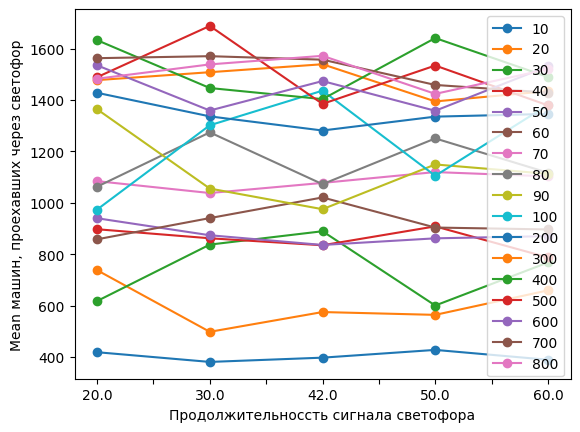

In [438]:
importlib.reload(analysis)

analysis.plots_mean_traffic(durations=durations, vehicles=vehicles_arr, pathToSave=gridsDataFolder)

----------running for duration:  20 -------------


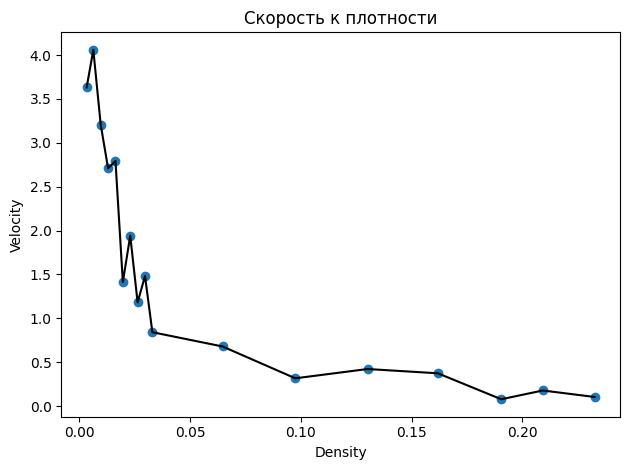

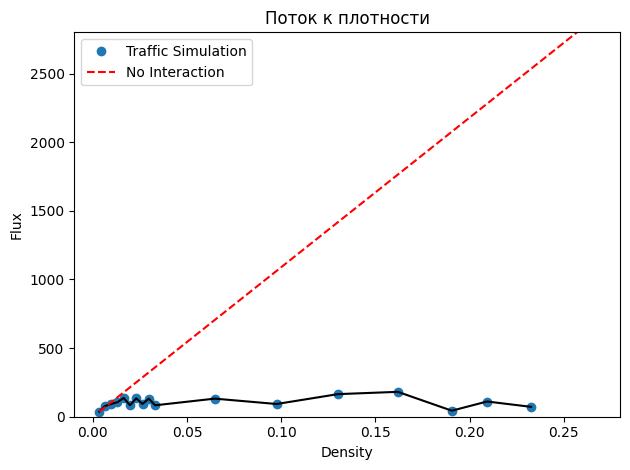

----------running for duration:  30 -------------


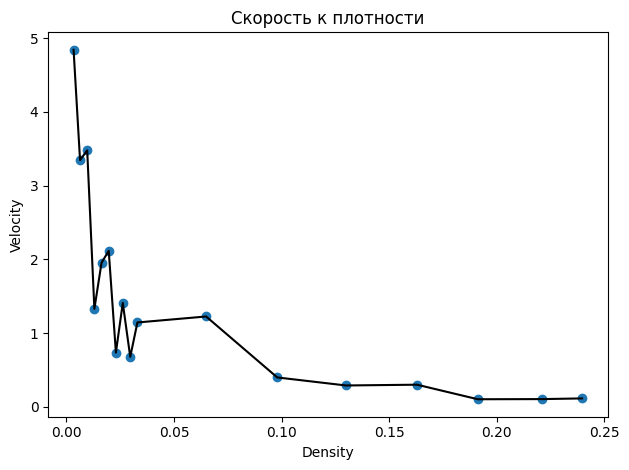

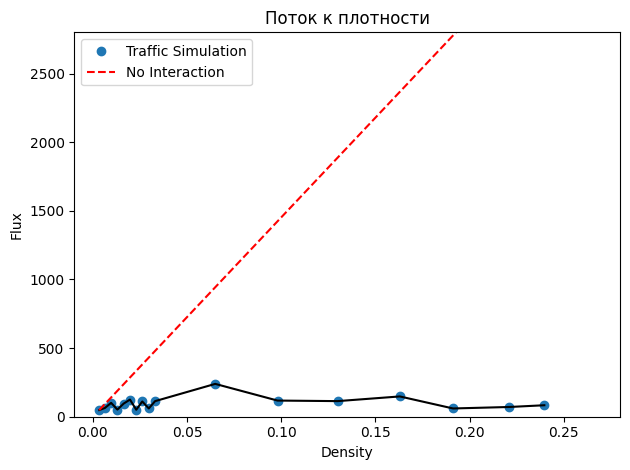

----------running for duration:  42 -------------


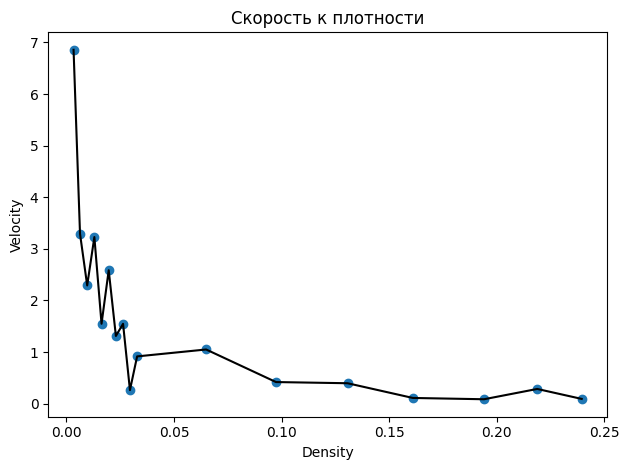

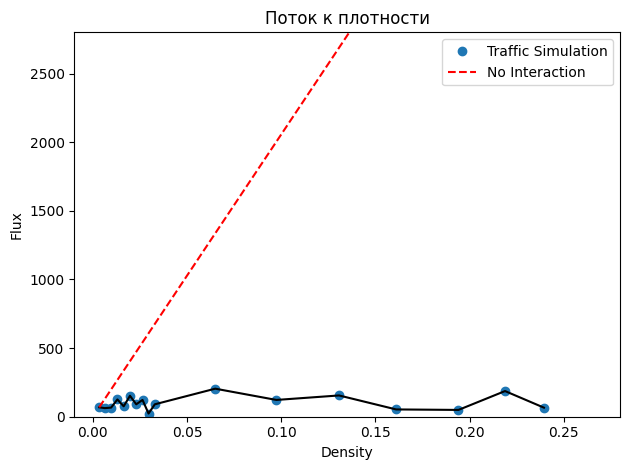

----------running for duration:  50 -------------


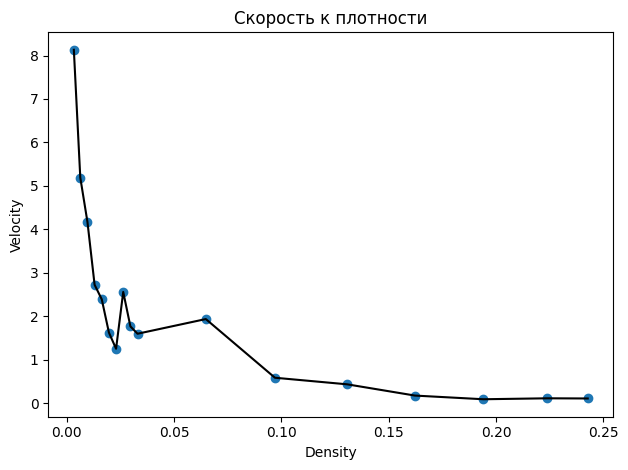

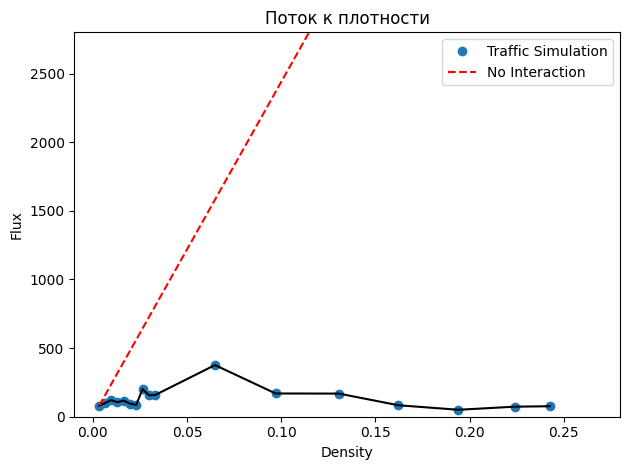

----------running for duration:  60 -------------


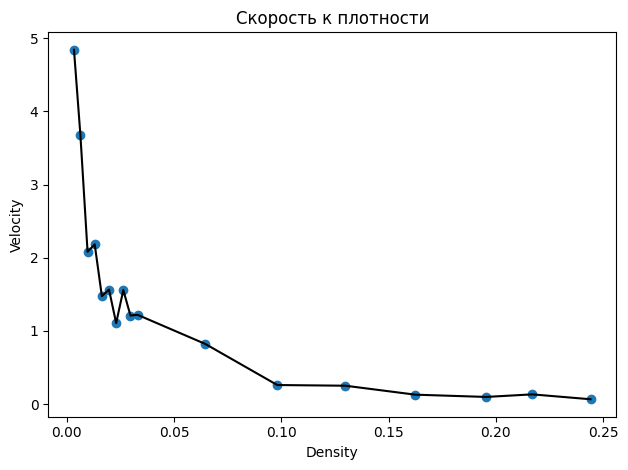

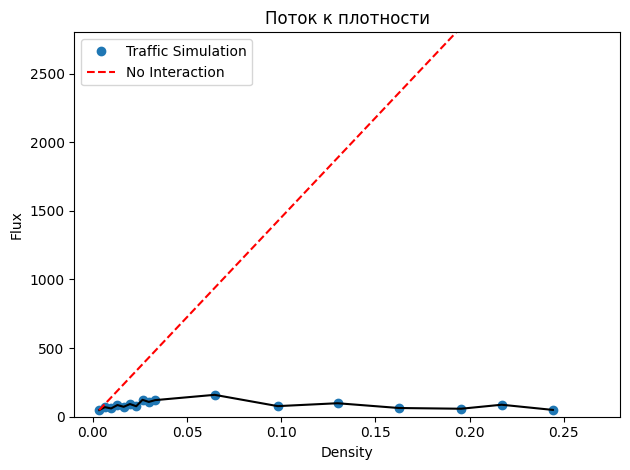

In [426]:
for duration in durations:
    print("----------running for duration: ", duration,"-------------")
    get_plots(                     
            vehicles_arr=vehicles_arr,
            pathToSave=gridsDataFolder,
            green_faze=duration,
            red_faze=duration
    )